In [1]:
from lib.artificial_data import ArtificialTrackDataset, generate_dataset_with_similarities
from lib.user_similarities import calculate_users_track_common_percentage
from lib.plotting import plot_user_similarities_matrix
from lib.matrix_dataset import MatrixDataset
from lib.spoti import NUMERICAL_FEATURES, PRETTY_PRINT_FEATURES
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
SIMPLIFIED_FEATURES = [
    "danceability",
    "energy",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "loudness",
    "duration_ms",
    "release_year",
    "time_signature",
    "popularity",
]

In [3]:
df_1 = ArtificialTrackDataset(
    default_value=2,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "owen"},
).randomize()

df_2 = ArtificialTrackDataset(
    default_value=3,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "paul"},
).randomize() \
.insert_some_tracks(df_1, 0.5, 0.5)[0] \
.randomize(["affinity"]) \
.shuffle()

df = df_1.merge(df_2)

display(df.data)

/Users/owen/local/unibe/ml/spotify-recommender/lib/artificial_data.py:139: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_dataset.data["id"][:n_replace] = other.data["id"][:n_replace]
/Users/owen/local/unibe/ml/spotify-recommender/lib/artificial_data.py:140: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_dataset.data[self.numerical_features][:n_replace] = other.data[


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity
0,Let matter stage decade environmental,owen,1.145273,0.869138,1.025702,0.729868,1.072749,0.836595,1.135281,0.943448,0.921765,1.133503,0.984619,0.886455,1.138196,1.170828,NaN
1,Real cover upon face role life hit,owen,1.106630,0.846093,1.096619,0.900947,0.916782,0.889891,1.010874,0.976723,0.963915,1.035489,0.946395,1.048703,0.898089,0.852849,NaN
2,Bed represent discuss pay song. Six challenge ...,owen,1.012677,0.883992,1.095850,0.872258,0.836688,1.130684,0.912599,0.920008,0.963183,1.054535,0.951348,1.027232,0.942841,0.994287,NaN
3,View fish quality leg some book better finally,owen,0.968834,1.029004,1.107686,1.157725,0.929607,1.056751,1.086404,0.841788,1.014322,1.059457,0.899456,1.141793,0.939766,1.145005,NaN
4,Position year success agency provide,owen,0.953104,0.963642,1.035205,1.032078,0.818363,1.110986,1.038885,1.132054,0.998948,1.028270,1.013080,0.886174,1.167715,0.881323,NaN
5,Forget scene decade serious foot give,paul,1.058167,0.935332,0.960759,0.973088,0.888799,0.923135,0.871060,0.963620,0.939846,0.905171,1.216091,0.829656,0.881012,0.929760,1.035840
6,Lot attack with. Mother along successful group,paul,1.021058,0.892822,1.056526,0.880881,1.024200,1.160929,1.298557,0.967571,1.046982,1.088894,1.003343,0.904725,1.062177,1.062728,1.046376
7,View fish quality leg some book better finally,paul,1.013980,1.128817,1.208449,0.963782,1.032880,1.147496,1.108772,1.085417,1.041145,1.050906,1.026277,1.147161,1.023648,1.087245,1.092004
8,Position year success agency provide,paul,1.073132,1.065485,0.981109,0.984220,0.976867,0.967704,1.006303,1.153719,1.022393,0.961603,1.060035,0.819137,1.079098,1.076870,0.919558
9,Different camera prove hotel. Among hot bag ea...,paul,0.987357,0.998811,0.924731,0.829756,0.827481,0.968459,0.807391,1.060794,0.941366,1.054925,0.938535,0.938928,0.988646,0.883924,0.872141


In [4]:
n_users = 8
df = generate_dataset_with_similarities(
    num_users=n_users,
    n_samples=np.random.randint(150, 2000, n_users).tolist(),
    numerical_features=SIMPLIFIED_FEATURES,
    affinity_feature="affinity",
    max_track_mixing_percentage=0.2,
    min_track_mixing_percentage=0.01,
    mix_with_someone_else_chance=0.85,
)
df.data

/Users/owen/local/unibe/ml/spotify-recommender/lib/artificial_data.py:139: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_dataset.data["id"][:n_replace] = other.data["id"][:n_replace]
/Users/owen/local/unibe/ml/spotify-recommender/lib/artificial_data.py:140: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_dataset.data[self.numerical_features][:n_replace] = other.data[
/Users/owen/local/unibe/ml/spotify-recommender/lib/artificial_data.py:139: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the doc

Mixing user John Salazar with James Lucas with a replacement percentage of 12.69%
Mixing user James Nguyen with John Salazar with a replacement percentage of 2.99%
Mixing user Steven Hardy with Shannon Pena with a replacement percentage of 1.67%
Mixing user Amanda Caldwell with Shannon Pena with a replacement percentage of 2.45%
Mixing user Shannon Pena with James Nguyen with a replacement percentage of 5.93%
Mixing user Thomas Frank with Shannon Pena with a replacement percentage of 2.55%
Mixing user James Lucas with Steven Hardy with a replacement percentage of 2.39%


/Users/owen/local/unibe/ml/spotify-recommender/lib/artificial_data.py:139: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_dataset.data["id"][:n_replace] = other.data["id"][:n_replace]
/Users/owen/local/unibe/ml/spotify-recommender/lib/artificial_data.py:140: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_dataset.data[self.numerical_features][:n_replace] = other.data[


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity
0,Interest town that help dream part,John Salazar,1.004278,1.066015,0.867160,1.012741,0.967624,0.927443,0.927099,0.782766,1.076600,1.058630,0.859641,0.786646,0.908543,0.873649,1.004040
1,Officer do daughter million international,John Salazar,0.986889,1.183436,0.998783,1.036802,1.248270,1.112894,1.087231,1.109391,1.114628,1.127957,1.066690,0.904340,1.055359,1.095351,1.128595
2,Resource safe both example save hot,John Salazar,1.031384,1.013980,0.898097,1.036348,1.073970,0.992812,0.879812,1.029994,1.044562,1.036791,1.016300,1.021387,0.931161,1.032702,1.159961
3,Firm notice Republican. Instead section offici...,John Salazar,0.905999,0.992160,0.906533,1.063785,0.957581,1.069793,0.999221,0.956547,0.874915,0.874221,0.825389,1.178520,0.871608,1.108854,1.222798
4,Research exactly information catch themselves ...,John Salazar,1.030859,1.080959,0.899832,1.100282,1.013760,1.049740,1.025140,0.963927,1.051930,1.216153,1.077051,1.000070,1.005593,0.964281,0.989819
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6391,Would there these kid financial effort purpose,James Lucas,1.025508,0.839551,0.912182,1.066888,0.828601,1.045004,1.131643,0.979570,0.803884,1.172215,0.969431,1.025340,0.983835,1.029666,0.981942
6392,South production song,James Lucas,0.993818,0.964673,0.969988,1.077769,1.133217,0.826661,0.931442,0.835881,0.985604,0.973569,1.015458,1.089874,0.954739,0.889764,0.947732
6393,Show what Mr two. This bring material action,James Lucas,1.061660,0.939879,0.876760,0.973434,0.961003,0.939195,1.084046,1.000883,0.863193,1.076837,0.970254,1.013445,1.036094,1.147216,1.140942
6394,Deal option southern large suggest record,James Lucas,0.990371,0.997787,1.027463,0.987888,1.061566,1.073118,0.968825,0.930999,1.074755,0.862950,1.130684,0.887693,0.808733,1.073535,0.987389


In [10]:
df.data.groupby("username").count()

,id,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity
username,,,,,,,,,,,,,,,,
Amanda Caldwell,163,163,163,163,163,163,163,163,163,163,163,163,163,163,163,163
Denise Ramos,1221,1221,1221,1221,1221,1221,1221,1221,1221,1221,1221,1221,1221,1221,1221,1221
James Lucas,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382,1382
James Nguyen,670,670,670,670,670,670,670,670,670,670,670,670,670,670,670,670
John Salazar,796,796,796,796,796,796,796,796,796,796,796,796,796,796,796,796
Shannon Pena,354,354,354,354,354,354,354,354,354,354,354,354,354,354,354,354
Steven Hardy,1260,1260,1260,1260,1260,1260,1260,1260,1260,1260,1260,1260,1260,1260,1260,1260
Thomas Frank,550,550,550,550,550,550,550,550,550,550,550,550,550,550,550,550


In [5]:
df.data.to_csv(os.path.join("data", f"artificial_data_{n_users}.csv"))

In [6]:
df_track_common = calculate_users_track_common_percentage(df.data, username_col="username", trackname_col="id")
df_track_common

username,Amanda Caldwell,Denise Ramos,James Lucas,James Nguyen,John Salazar,Shannon Pena,Steven Hardy,Thomas Frank
username,,,,,,,,
Amanda Caldwell,1.000000,0.0,0.000000,0.000000,0.000000,0.024540,0.000000,0.000000
Denise Ramos,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
James Lucas,0.000000,0.0,1.000000,0.000000,0.072359,0.000000,0.023878,0.000000
James Nguyen,0.000000,0.0,0.000000,1.000000,0.028358,0.031343,0.000000,0.000000
John Salazar,0.000000,0.0,0.125628,0.023869,1.000000,0.000000,0.000000,0.000000
Shannon Pena,0.011299,0.0,0.000000,0.059322,0.000000,1.000000,0.053672,0.033898
Steven Hardy,0.000000,0.0,0.026190,0.000000,0.000000,0.015079,1.000000,0.000794
Thomas Frank,0.000000,0.0,0.000000,0.000000,0.000000,0.021818,0.001818,1.000000


In [7]:
df.data[df.data.isna().any(axis=1)]

,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity


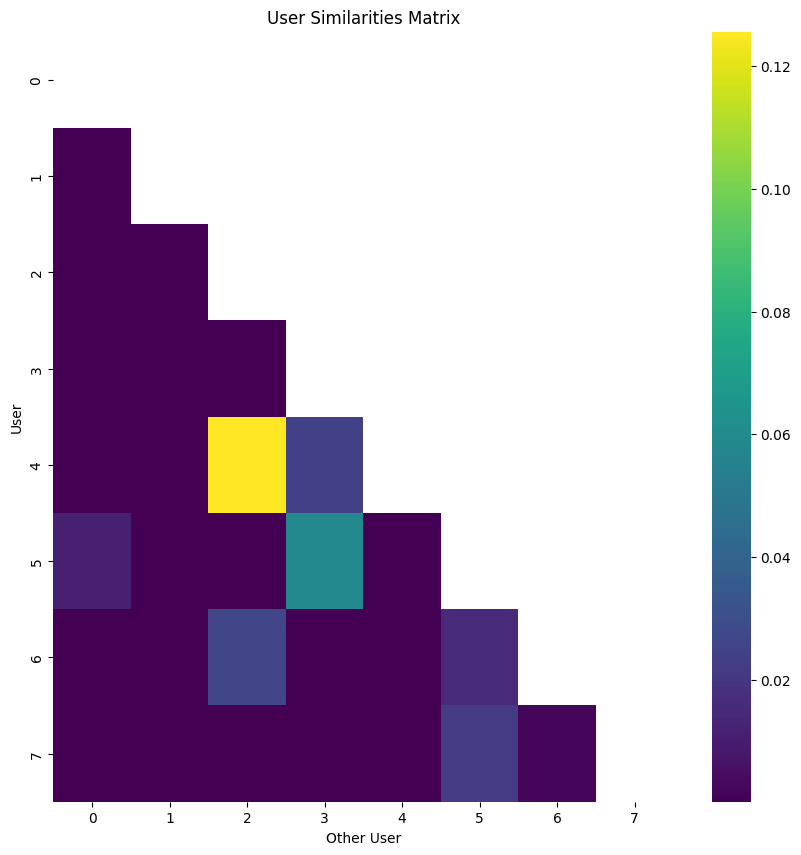

In [8]:
plot_user_similarities_matrix(df_track_common, figsize=(10, 10), log_scale=False)

In [9]:
M = MatrixDataset(df.data, user_col="username", item_col="id", value_col="affinity")
M.R.shape

torch.Size([8, 6188])